First 5 rows:

                 Price
Date                  
2025-01-01  101.764052
2025-01-02  102.164210
2025-01-03  103.142948
2025-01-04  105.383841
2025-01-05  107.251399

Summary Statistics:

count    365.000000
mean     108.180518
std        6.738268
min       92.864443
25%      102.723659
50%      108.288266
75%      113.812917
max      120.585036
Name: Price, dtype: float64

Data with Moving Averages:

                 Price  Daily Return        MA_7  MA_30
Date                                                   
2025-01-01  101.764052           NaN         NaN    NaN
2025-01-02  102.164210      0.003932         NaN    NaN
2025-01-03  103.142948      0.009580         NaN    NaN
2025-01-04  105.383841      0.021726         NaN    NaN
2025-01-05  107.251399      0.017721         NaN    NaN
2025-01-06  106.274121     -0.009112         NaN    NaN
2025-01-07  107.224209      0.008940  104.743540    NaN
2025-01-08  107.072852     -0.001412  105.501940    NaN
2025-01-09  106.969633   

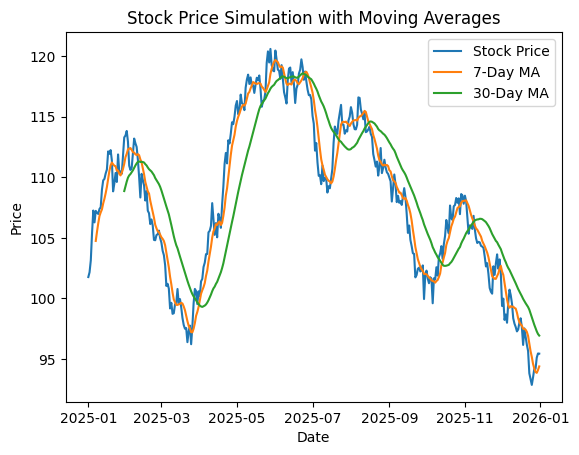

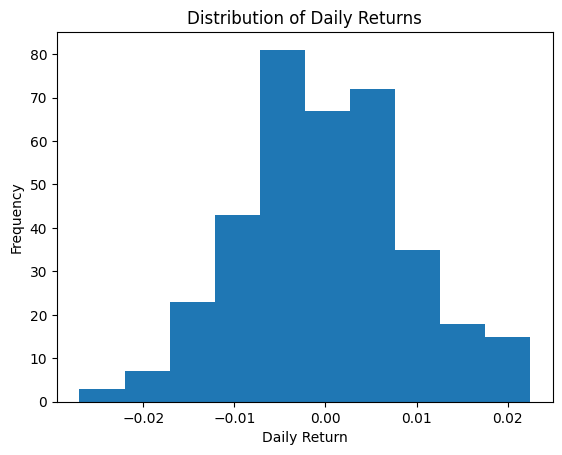

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Create date range for one year
dates = pd.date_range(start='2025-01-01', periods=365, freq='D')

# Simulate stock prices using random walk
np.random.seed(0)
price = 100  # initial stock price
prices = []

for i in range(365):
    daily_change = np.random.normal(0, 1)  # small random change
    price += daily_change
    prices.append(price)

# Create DataFrame
df = pd.DataFrame({
    'Date': dates,
    'Price': prices
})

# Set Date as index
df.set_index('Date', inplace=True)

print("First 5 rows:\n")
print(df.head())




# Summary statistics
print("\nSummary Statistics:\n")
print(df['Price'].describe())

# Daily returns
df['Daily Return'] = df['Price'].pct_change()

# Moving averages
df['MA_7'] = df['Price'].rolling(window=7).mean()
df['MA_30'] = df['Price'].rolling(window=30).mean()

print("\nData with Moving Averages:\n")
print(df.head(10))




# Plot stock price and moving averages
plt.figure()
plt.plot(df.index, df['Price'], label='Stock Price')
plt.plot(df.index, df['MA_7'], label='7-Day MA')
plt.plot(df.index, df['MA_30'], label='30-Day MA')

plt.title('Stock Price Simulation with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Plot daily returns distribution
plt.figure()
plt.hist(df['Daily Return'].dropna())

plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()